# Project Requirements
Download the UCI Online Retail Dataset (available on Kaggle or the UCI ML Repository)

Sample 10% of rows to keep things manageable

Clean the data: remove nulls, fix data types, filter out returns, and free items

Convert InvoiceDate to a proper datetime object

Create a Revenue column (Quantity × UnitPrice)

Find the top 10 countries by total revenue and plot the result

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel(r"C:\Users\Dhyaneshwari\Downloads\online+retail\Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Rows with Quantity <= 0 :", (df["Quantity"] <= 0).sum())
print("Rows with UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print("Invoices starting with 'C' (cancellations):", df["InvoiceNo"].astype(str).str.startswith("C").sum())

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Rows with Quantity <= 0 : 10624
Rows with UnitPrice <= 0: 2517
Invoices starting with 'C' (cancellations): 9288


**What we usually find in this dataset**
- `CustomerID` has many nulls (guest checkouts / untracked orders).
- `Description` has some nulls.
- Negative `Quantity` = returns / cancellations (invoice numbers starting with `C`).
- `UnitPrice` of 0 = free items, samples or data-entry adjustments.

In [8]:
rows_start = len(df)
print("Rows before cleaning:", rows_start)

Rows before cleaning: 541909


In [9]:
before = len(df)
df = df.dropna(subset=["CustomerID", "Description"])
print(f"Removed {before - len(df):,} rows with nulls. Remaining: {len(df):,}")

Removed 135,080 rows with nulls. Remaining: 406,829


In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceNo"]   = df["InvoiceNo"].astype(str)
df["StockCode"]   = df["StockCode"].astype(str)
df["Country"]     = df["Country"].astype(str).str.strip()

In [11]:
before = len(df)
df = df[(df["Quantity"] > 0) & (~df["InvoiceNo"].str.startswith("C"))]
print(f"Removed {before - len(df):,} return rows. Remaining: {len(df):,}")

Removed 8,905 return rows. Remaining: 397,924


In [12]:
before = len(df)
df = df[df["UnitPrice"] > 0]
print(f"Removed {before - len(df):,} free-item rows. Remaining: {len(df):,}")

Removed 40 free-item rows. Remaining: 397,884


In [13]:
rows_end = len(df)
print(f"Rows before cleaning : {rows_start:,}")
print(f"Rows after cleaning  : {rows_end:,}")
print(f"Total removed        : {rows_start - rows_end:,} ({(rows_start - rows_end) / rows_start:.1%})")
print()
print("Remaining nulls:", df.isna().sum().sum())
print("Min Quantity :", df["Quantity"].min())
print("Min UnitPrice:", df["UnitPrice"].min())
print("Date range   :", df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())

Rows before cleaning : 541,909
Rows after cleaning  : 397,884
Total removed        : 144,025 (26.6%)

Remaining nulls: 0
Min Quantity : 1
Min UnitPrice: 0.001
Date range   : 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


In [14]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df[["InvoiceNo", "Quantity", "UnitPrice", "Revenue"]].head()

,InvoiceNo,Quantity,UnitPrice,Revenue
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


In [15]:
top10 = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top10_df = top10.reset_index()
top10_df["Share_of_Total_%"] = (top10_df["Revenue"] / df["Revenue"].sum() * 100).round(2)
top10_df

,Country,Revenue,Share_of_Total_%
0,United Kingdom,7308391.554,82.01
1,Netherlands,285446.340,3.20
2,EIRE,265545.900,2.98
3,Germany,228867.140,2.57
4,France,209024.050,2.35
5,Australia,138521.310,1.55
6,Spain,61577.110,0.69
7,Switzerland,56443.950,0.63
8,Belgium,41196.340,0.46
9,Sweden,38378.330,0.43


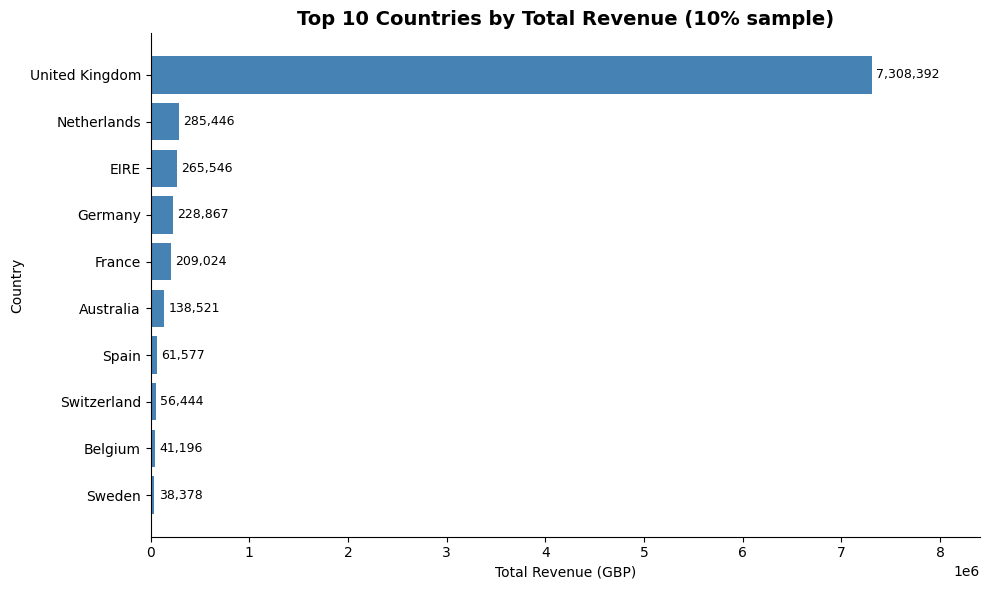

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = top10.sort_values()           # ascending so largest is on top in barh
bars = ax.barh(plot_data.index, plot_data.values, color="steelblue")
ax.set_title("Top 10 Countries by Total Revenue (10% sample)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (GBP)")
ax.set_ylabel("Country")
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in plot_data.values], padding=3, fontsize=9)
ax.set_xlim(0, plot_data.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

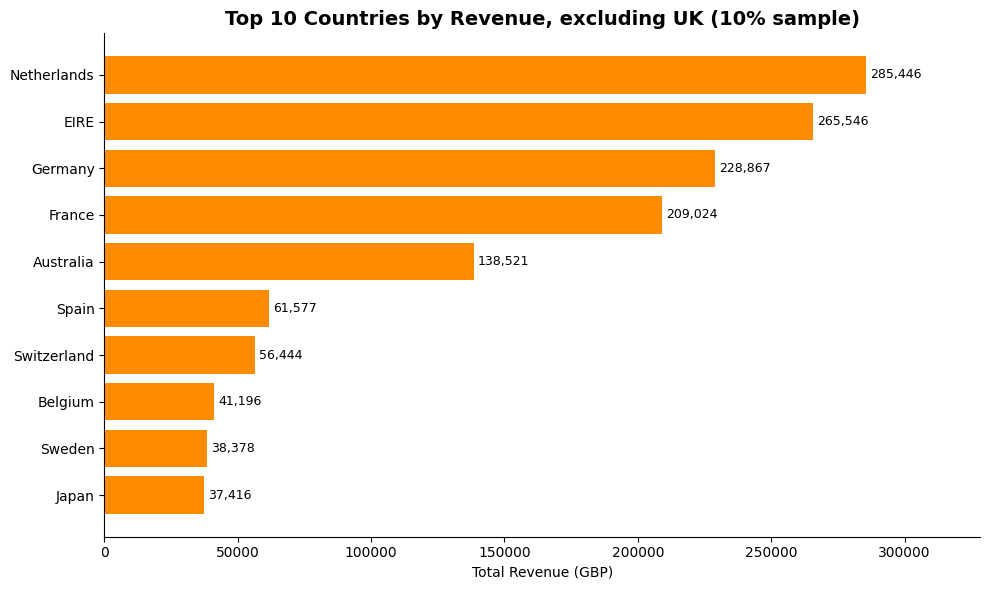

In [17]:
top10_no_uk = (
    df[df["Country"] != "United Kingdom"]
      .groupby("Country")["Revenue"].sum()
      .sort_values(ascending=False).head(10)
)
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = top10_no_uk.sort_values()
bars = ax.barh(plot_data.index, plot_data.values, color="darkorange")
ax.set_title("Top 10 Countries by Revenue, excluding UK (10% sample)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (GBP)")
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in plot_data.values], padding=3, fontsize=9)
ax.set_xlim(0, plot_data.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()